# Bibliotecas

In [192]:
import os

import json

import pandas as pd
import numpy as np
import yaml

import matplotlib.pyplot as plt
import seaborn as sns

import shutil

from tqdm.notebook import tqdm


from sklearn.model_selection import train_test_split

# Extração de informações no Dataset

In [2]:
PATH = "/Users/lucas/Documents/Datasets/paper-parts"

In [ ]:
dados = yaml.safe_load(open(PATH + "/data.yaml"))
names = dados.get("names")

names_map = {k:v for k,v in enumerate(names)}

In [104]:
print(json.dumps(names,indent=1))

[
 "author",
 "chapter",
 "equation",
 "equation number",
 "figure",
 "figure caption",
 "footnote",
 "list of content heading",
 "list of content text",
 "page number",
 "paragraph",
 "reference text",
 "section",
 "subsection",
 "subsubsection",
 "table",
 "table caption",
 "table of contents text",
 "title"
]


In [ ]:
"figure",
 "figure caption",
 "section",
 "subsection",
 "subsubsection",
 "table",
 "table caption",
]

In [105]:
print(json.dumps(names_map,indent=1))

{
 "0": "author",
 "1": "chapter",
 "2": "equation",
 "3": "equation number",
 "4": "figure",
 "5": "figure caption",
 "6": "footnote",
 "7": "list of content heading",
 "8": "list of content text",
 "9": "page number",
 "10": "paragraph",
 "11": "reference text",
 "12": "section",
 "13": "subsection",
 "14": "subsubsection",
 "15": "table",
 "16": "table caption",
 "17": "table of contents text",
 "18": "title"
}


In [32]:
df = list()

for root_, _, files_ in os.walk(PATH):
    if(files_):
        for file_ in files_:
            aux = [0]*len(names)
            if(file_.endswith(".txt")):
                path = f"{root_}/{file_}"
                
                with open(path,"r") as infile:
                    data = infile.readlines()
                    infile.close()
        
                data = [int(x.replace("\n","").split(" ")[0]) for x in data]

                # contando a quantidade de dados por arquivo
                for cls in data:
                    aux[cls] += 1

                if("train" in path):
                    label = "Train"
                elif("val" in path):
                    label = "Val"
                elif("test" in path):
                    label = "Test"

                df.append([path,*aux,label])

df = pd.DataFrame(df,columns=["path",*names,"Label"])

# Comparativo de proporções

In [122]:
df_prop = df.drop(["path"],axis=1).groupby("Label").sum()
df_prop = df_prop.reindex(["Train","Val","Test"])
df_prop_porc = round(df_prop/df_prop.sum(axis=0),2)
df_prop_porc.index = pd.Index(["Train %","Val %","Test %"],name="Label")

df_prop_concat = pd.concat([df_prop,df_prop_porc]).T
df_prop_concat.sort_values(["Train","Val","Test"],axis=0,ascending=False,inplace=True)
df_prop_concat

Label,Train,Val,Test,Train %,Val %,Test %
paragraph,10891.0,2649.0,1530.0,0.72,0.18,0.10
page number,8315.0,2326.0,1192.0,0.70,0.20,0.10
equation,2603.0,308.0,225.0,0.83,0.10,0.07
figure,2248.0,481.0,377.0,0.72,0.15,0.12
figure caption,2001.0,446.0,373.0,0.71,0.16,0.13
subsection,1522.0,265.0,190.0,0.77,0.13,0.10
section,1389.0,244.0,83.0,0.81,0.14,0.05
equation number,1375.0,120.0,201.0,0.81,0.07,0.12
table,884.0,231.0,70.0,0.75,0.19,0.06
table caption,800.0,90.0,63.0,0.84,0.09,0.07


# Criando classes

In [145]:
list_classe = list()
for _, row_ in df.drop(["path","Label"],axis=1).iterrows():
    classe_ = "_".join(list(map(lambda x: "1" if x else "0",(row_ >= 1).to_list())))
    list_classe.append(classe_)

df_classe = df.copy()
df_classe["Classe"] = list_classe

df_classe_qtd = df_classe[["Classe","Label"]].groupby(["Classe","Label"]).size().to_frame(name="Qtd").reset_index()
df_classe_qtd

,Classe,Label,Qtd
0,0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0,Train,5
1,0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_1,Test,3
2,0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_1,Train,9
3,0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_1_0,Train,7
4,0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_0_1_0,Val,1
...,...,...,...
421,1_0_0_0_0_0_0_0_0_0_0_0_0_0_0_1_0_0_0,Val,2
422,1_0_0_0_0_0_0_0_0_0_1_0_0_0_0_0_0_0_1,Train,1
423,1_0_0_0_0_0_0_0_0_1_0_0_0_0_0_0_0_0_1,Test,2
424,1_0_0_0_0_0_0_0_0_1_0_0_0_0_0_0_0_0_1,Train,36


In [146]:
df_classe

,path,author,chapter,equation,equation number,figure,figure caption,footnote,list of content heading,list of content text,...,reference text,section,subsection,subsubsection,table,table caption,table of contents text,title,Label,Classe
0,/Users/lucas/Documents/Datasets/paper-parts/va...,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,Val,0_0_0_0_0_0_0_0_0_1_0_1_0_0_0_0_0_0_0
1,/Users/lucas/Documents/Datasets/paper-parts/va...,0,0,5,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,Val,0_0_1_1_0_0_0_0_0_1_1_0_0_1_0_0_0_0_0
2,/Users/lucas/Documents/Datasets/paper-parts/va...,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,Val,0_0_0_0_0_0_1_0_0_1_1_0_0_0_0_0_0_0_0
3,/Users/lucas/Documents/Datasets/paper-parts/va...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,Val,0_0_0_0_0_0_0_0_0_1_1_0_0_0_0_1_0_0_0
4,/Users/lucas/Documents/Datasets/paper-parts/va...,0,0,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,0,Val,0_0_0_0_0_0_1_0_0_1_1_0_0_1_0_1_0_0_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12035,/Users/lucas/Documents/Datasets/paper-parts/tr...,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,Train,0_0_0_0_0_0_0_0_0_1_0_1_0_0_0_0_0_0_0
12036,/Users/lucas/Documents/Datasets/paper-parts/tr...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Train,0_0_0_0_0_0_0_0_0_1_1_0_0_0_0_0_0_0_0
12037,/Users/lucas/Documents/Datasets/paper-parts/tr...,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,Train,0_0_0_0_0_0_1_0_0_1_1_0_0_0_1_0_0_0_0
12038,/Users/lucas/Documents/Datasets/paper-parts/tr...,0,0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Train,0_0_1_0_0_0_0_0_0_1_1_0_0_0_0_0_0_0_0


## Avaliando os splits

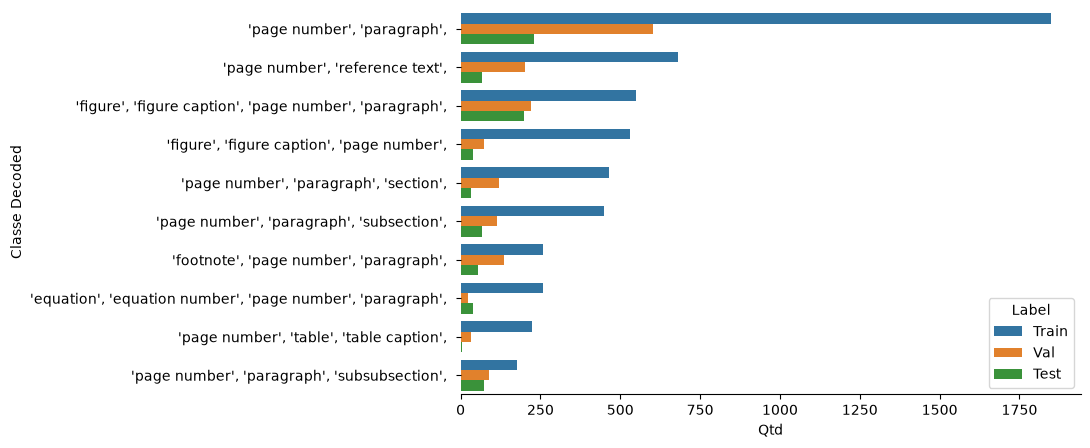

In [144]:
df_classe_qtd_train = df_classe_qtd.sort_values("Qtd",axis=0,ascending=False)

name_classe_list = list()
for classe_ in df_classe_qtd_train["Classe"]:
    name_classe = ""
    for idx, val in enumerate(classe_.split("_")):
        if(val == "1"):
            name_classe += f"'{names_map[idx]}', "

    name_classe_list.append(name_classe)

df_classe_qtd_train["Classe Decoded"] = name_classe_list

higher_qtd_classes = df_classe_qtd_train[df_classe_qtd_train["Label"]=="Train"]["Classe Decoded"][:10].to_list()

df_classe_qtd_train = df_classe_qtd_train[df_classe_qtd_train["Classe Decoded"].apply(lambda x: x in higher_qtd_classes)]

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=df_classe_qtd_train,x="Qtd",y="Classe Decoded",hue="Label")

sns.despine(fig,ax,top=True,left=True)

plt.show()

# Separando dataset

In [154]:
classes_interesse = [
 "figure",
 "figure caption",
 "section",
 "subsection",
 "subsubsection",
 "table",
 "table caption",
]

df_list = list()

for col in classes_interesse:
    df_list.append(df_classe[df_classe[col] > 0])

In [161]:
df_interesse = pd.concat(df_list)
df_interesse.drop_duplicates(["path"],inplace=True)
df_interesse.reset_index(inplace=True,drop=True)

In [165]:
df_interesse["Classe"].value_counts().to_frame("Qtd")

,Qtd
Classe,
0_0_0_0_1_1_0_0_0_1_1_0_0_0_0_0_0_0_0,969
0_0_0_0_1_1_0_0_0_1_0_0_0_0_0_0_0_0_0,643
0_0_0_0_0_0_0_0_0_1_1_0_0_1_0_0_0_0_0,629
0_0_0_0_0_0_0_0_0_1_1_0_1_0_0_0_0_0_0,619
0_0_0_0_0_0_0_0_0_1_1_0_0_0_1_0_0_0_0,338
...,...
0_0_1_1_0_0_0_0_0_1_0_0_0_0_0_1_1_0_0,1
0_1_0_0_0_0_0_0_0_1_1_0_0_0_0_1_0_0_0,1
0_0_0_1_0_0_0_0_0_1_1_0_0_0_0_1_1_0_0,1


In [169]:
counts = df_interesse["Classe"].value_counts()

df_single = df_interesse[df_interesse["Classe"].isin(counts[counts == 1].index)]
df_multi = df_interesse[df_interesse["Classe"].isin(counts[counts > 1].index)]

df_train, df_val = train_test_split(
    df_multi,
    stratify=df_multi["Classe"],
    random_state=64,
    test_size=0.3
)

df_train = pd.concat([df_train, df_single], ignore_index=True)

In [183]:
df_train.drop(["path","Label","Classe"],axis=1).T.sum(axis=1).to_frame("Qtd").sort_values("Qtd")

,Qtd
title,0
list of content heading,0
list of content text,1
author,1
table of contents text,2
reference text,20
footnote,212
chapter,282
equation number,595
table caption,673


In [184]:
df_val.drop(["path","Label","Classe"],axis=1).T.sum(axis=1).to_frame("Qtd").sort_values("Qtd")

,Qtd
title,0
table of contents text,0
list of content text,0
list of content heading,0
author,1
reference text,6
footnote,86
chapter,114
equation number,249
table caption,280


# Salvando dados

In [ ]:
dir_output = "/Users/lucas/Documents/Datasets/paper-parts-v1"

os.makedirs(dir_output,exist_ok=True)

for x in ["images","labels"]:
    for y in ["train","val","test"]:
        path = f"{dir_output}/{x}/{y}"
        os.makedirs(path,exist_ok=True)

In [194]:
for path_ in tqdm(df_val["path"]):
    name = path_.split("/")[-1][:-4]
    source = path_
    target = f"{dir_output}/labels/test/{name}.txt"
    shutil.copy(source,target)

    source_img = source.replace("/labels/","/images/").replace(".txt",".jpg")
    target_img = f"{dir_output}/images/test/{name}.jpg"
    shutil.copy(source_img,target_img)

  0%|          | 0/1903 [00:00<?, ?it/s]

In [195]:
for path_ in tqdm(df_train["path"]):
    name = path_.split("/")[-1][:-4]
    source = path_
    target = f"{dir_output}/labels/train/{name}.txt"
    shutil.copy(source,target)

    source_img = source.replace("/labels/","/images/").replace(".txt",".jpg")
    target_img = f"{dir_output}/images/train/{name}.jpg"
    shutil.copy(source_img,target_img)

  0%|          | 0/4515 [00:00<?, ?it/s]

In [200]:
shutil.copy(PATH + "/data.yaml",f"{dir_output}/data.yaml")

'/Users/lucas/Documents/Datasets/paper-parts-v1/data.yaml'